## 두 LoRA의 hidden representation 분산 비교 검정
- 이표본 일변량 레빈 검정

In [ ]:
import numpy as np
from scipy import stats
import json

DATA_PATH = [
    "/Users/yoon/IRDMLab/PRAG/Q_noise_v2/mean_pooling_output/doc0_hidden_representation.json", 
    "/Users/yoon/IRDMLab/PRAG/Q_noise_v2/mean_pooling_output/doc1_hidden_representation.json"
]

doc0 = []
doc1 = []

for i, data in enumerate(DATA_PATH):
    with open(data, "r", encoding="utf-8") as f:
        doc_data = json.load(f)
    
    if i == 0:
        doc0.extend([item["hidden_representation"] for item in doc_data])
    else:
        doc1.extend([item["hidden_representation"] for item in doc_data])

# 유의수준 (Significance Level)
ALPHA = 0.05  

print("==================================================")
print(" 📊 OOD 탐지를 위한 Hidden Representation 통계 검정")
print("==================================================\n")

# ==========================================
# Step 1: 등분산 검정 (Levene's Test)
# ==========================================
# H0: 두 집단의 분산은 동일하다.
# H1: 두 집단의 분산은 다르다.
stat_levene, p_levene = stats.levene(scores_doc0, scores_doc1)

print(f"[1단계] 르벤 검정 (Levene's Test)")
print(f" - 검정 통계량 (W): {stat_levene:.4f}")
print(f" - p-value: {p_levene:.4f}")

if p_levene > ALPHA:
    print(f" 👉 결론: p-value > {ALPHA} 이므로 귀무가설(등분산) 채택.")
    print(" 👉 조치: 분산이 같다고 가정하고 'Student\'s t-test'를 수행합니다.\n")
    equal_var_assumption = True
else:
    print(f" 👉 결론: p-value <= {ALPHA} 이므로 귀무가설 기각 (이분산).")
    print(" 👉 조치: 분산이 다르다고 가정하고 'Welch\'s t-test'를 수행합니다.\n")
    equal_var_assumption = False

# ==========================================
# Step 2: 평균 차이 검정 (T-test or Welch's)
# ==========================================
# H0: 두 집단의 평균은 동일하다.
# H1: 두 집단의 평균은 통계적으로 유의미한 차이가 있다.



# equal_var 파라미터에 앞선 르벤 검정의 결과를 그대로 전달하여 알맞은 검정을 자동 수행
stat_t, p_t = stats.ttest_ind(scores_doc0, scores_doc1, equal_var=equal_var_assumption)

test_name = "Student's t-test" if equal_var_assumption else "Welch's t-test"

print(f"[2단계] {test_name}")
print(f" - 검정 통계량 (t): {stat_t:.4f}")
print(f" - p-value: {p_t:.4f}")

print("\n==================================================")
print(" 📝 최종 결론 (Conclusion)")
print("==================================================")
if p_t > ALPHA:
    print(f"결론: p-value({p_t:.4f}) > {ALPHA} 이므로 귀무가설 채택.")
    print("해석: 두 문서의 Hidden Representation (Z-score L2 Norm) 분포는 통계적으로 차이가 없습니다.")
    print("논문 작성 팁: '단순 거리 척도로는 도메인 간의 내적 표상 차이를 구분할 수 없음을 통계적으로 입증하였으며, 이를 극복하기 위해 다차원 공분산을 고려하는 마할라노비스 거리 도입의 당위성을 확보하였다.'라고 서술하세요.")
else:
    print(f"결론: p-value({p_t:.4f}) <= {ALPHA} 이므로 귀무가설 기각.")
    print("해석: 시각적으로는 유사해 보였으나, 통계적으로 두 문서의 분포에는 유의미한 차이가 존재합니다.")
    print("논문 작성 팁: '시각적 중첩성(Overlapping)에도 불구하고 T-검정 결과 두 도메인의 표상은 통계적으로 유의미한 차이(p<0.05)를 보였다. 이는 모델이 각 도메인을 다르게 인식하고 있음을 시사하며, 이 미세한 신호를 증폭시켜 노이즈 필터링에 활용하기 위해 추가적인 고도화(Mahalanobis)를 진행하였다.'라고 서술하세요.")

## 문서 A와 B에서 뽑은 100개 질문의 hidden representation의 Z score 분포 시각화

(100, 2048)
(100, 2048)


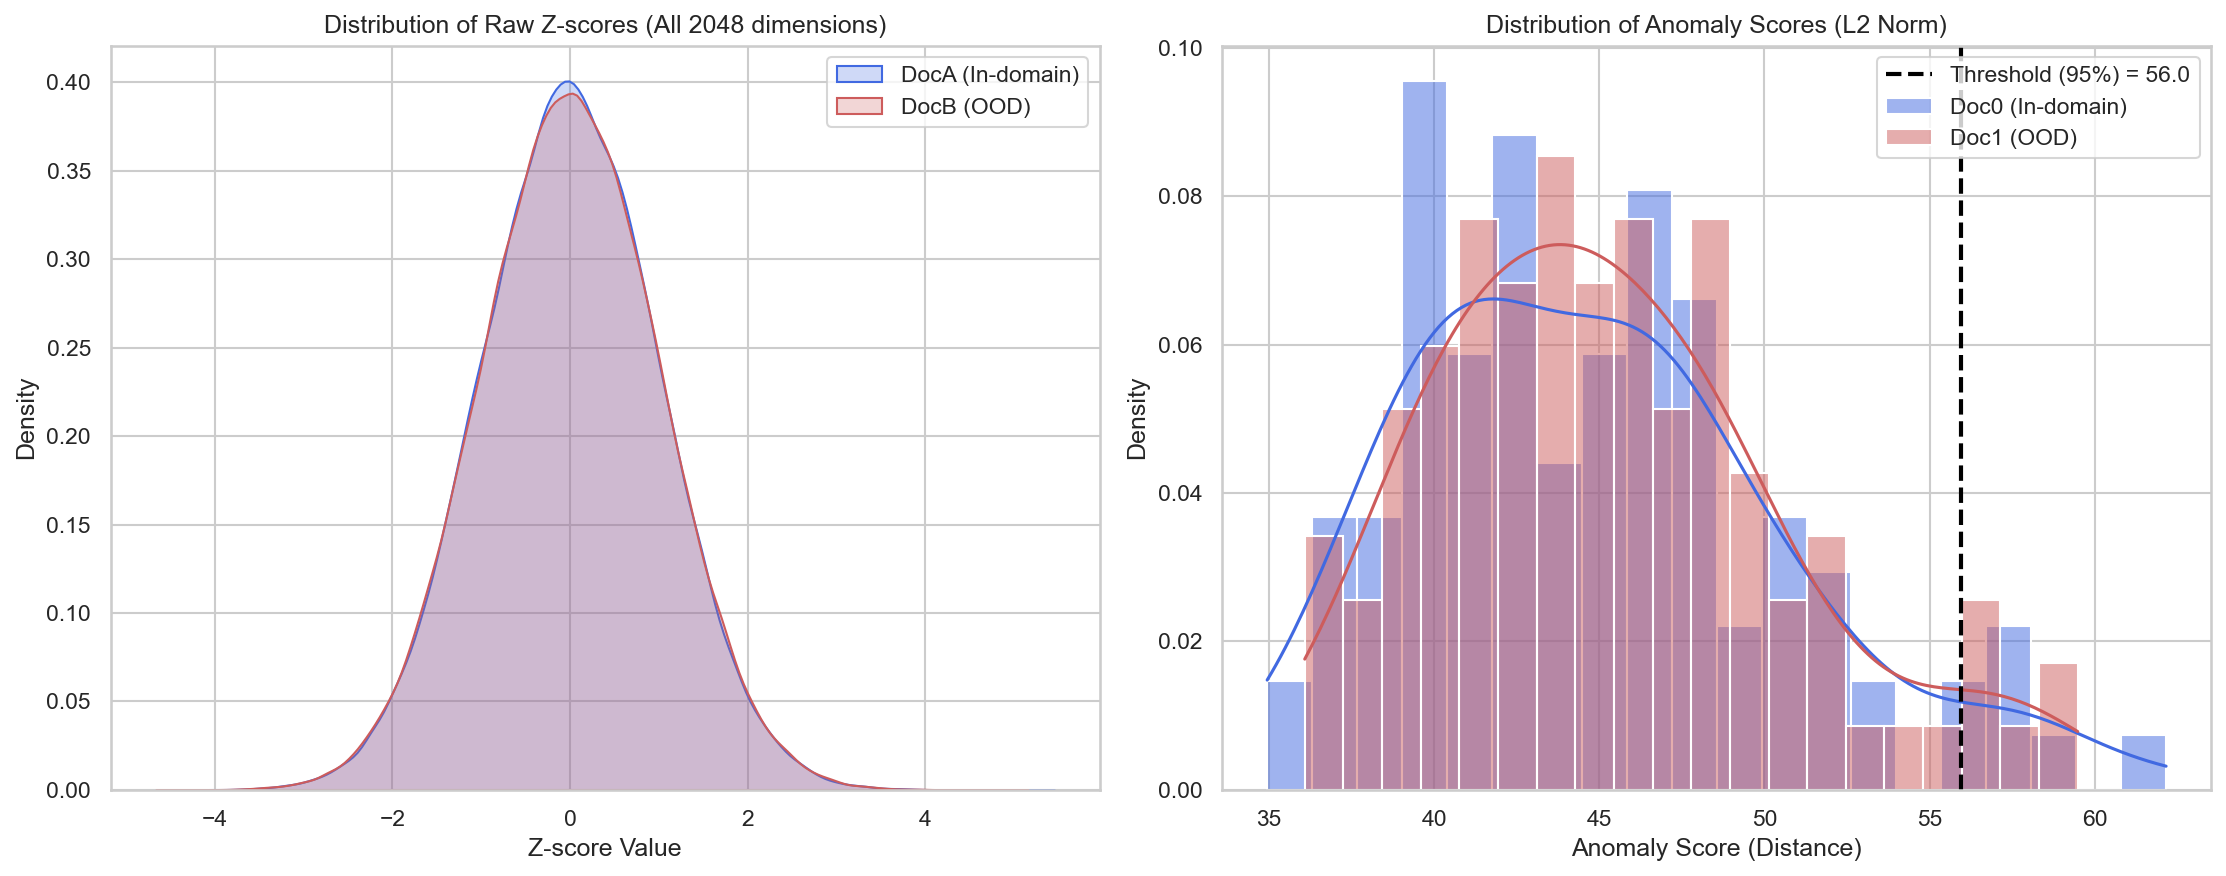

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

DATA_PATH = [
    "/Users/yoon/IRDMLab/PRAG/Q_noise_v2/output/pre/doc0_hidden_representation.json", 
    "/Users/yoon/IRDMLab/PRAG/Q_noise_v2/output/pre/doc1_hidden_representation.json"
]

doc0 = []
doc1 = []

for i, data in enumerate(DATA_PATH):
    with open(data, "r", encoding="utf-8") as f:
        doc_data = json.load(f)
    
    if i == 0:
        doc0.extend([item["hidden_representation"] for item in doc_data])
    else:
        doc1.extend([item["hidden_representation"] for item in doc_data])

data_matrix0 = np.array(doc0)
data_matrix1 = np.array(doc1)

print(data_matrix0.shape)
print(data_matrix1.shape)

# ==========================================
# 2. In-domain(doc0) 기준 프로필 생성
# ==========================================
mean0 = np.mean(data_matrix0, axis=0)
std0 = np.std(data_matrix0, axis=0) + 1e-8

# ==========================================
# 3. Z-score 계산 (★ doc0의 mean, std를 공통 기준으로 사용)
# ==========================================
# doc0의 Z-score (정상 데이터이므로 평균 0, 표준편차 1의 정규분포를 따를 것입니다)
z_scores_doc0 = (data_matrix0 - mean0) / std0

# doc1의 Z-score (doc0 기준으로 얼마나 벗어났는지 확인)
z_scores_doc1 = (data_matrix1 - mean0) / std0

# ==========================================
# 4. Anomaly Score (L2 Norm) 계산
# ==========================================
# 각 질문(행) 별로 2048개 차원의 Z-score를 L2 Norm으로 압축
anomaly_scores_doc0 = np.linalg.norm(z_scores_doc0, axis=1)
anomaly_scores_doc1 = np.linalg.norm(z_scores_doc1, axis=1)

# ==========================================
# 5. 시각화 (2개의 그래프를 나란히 비교)
# ==========================================
plt.rcParams['figure.dpi'] = 150
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- [그래프 1] 2048개 차원 전체의 Z-score 값 자체의 분포 ---
# 모든 차원의 값을 1차원으로 쭉 펼쳐서(flatten) 전체적인 값의 분포를 봅니다.
sns.kdeplot(z_scores_doc0.flatten(), fill=True, color="royalblue", label="DocA (In-domain)", ax=axes[0])
sns.kdeplot(z_scores_doc1.flatten(), fill=True, color="indianred", label="DocB (OOD)", ax=axes[0])

axes[0].set_title("Distribution of Raw Z-scores (All 2048 dimensions)")
axes[0].set_xlabel("Z-score Value")
axes[0].set_ylabel("Density")
axes[0].legend()
# doc0는 정규분포(N(0,1)) 형태를 띠지만, doc1은 중심이 이동했거나 꼬리가 두꺼워진 것을 확인할 수 있습니다.

# --- [그래프 2] 최종 Anomaly Score (L2 Norm) 분포 ---
sns.histplot(anomaly_scores_doc0, bins=20, color="royalblue", alpha=0.5, stat="density", kde=True, label="Doc0 (In-domain)", ax=axes[1])
sns.histplot(anomaly_scores_doc1, bins=20, color="indianred", alpha=0.5, stat="density", kde=True, label="Doc1 (OOD)", ax=axes[1])

# In-domain(doc0)의 상위 95% 지점에 Threshold 선 긋기
threshold_95 = np.percentile(anomaly_scores_doc0, 95)
axes[1].axvline(threshold_95, color='black', linestyle='--', linewidth=2, label=f'Threshold (95%) = {threshold_95:.1f}')

axes[1].set_title("Distribution of Anomaly Scores (L2 Norm)")
axes[1].set_xlabel("Anomaly Score (Distance)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

(100, 2048)
(100, 2048)


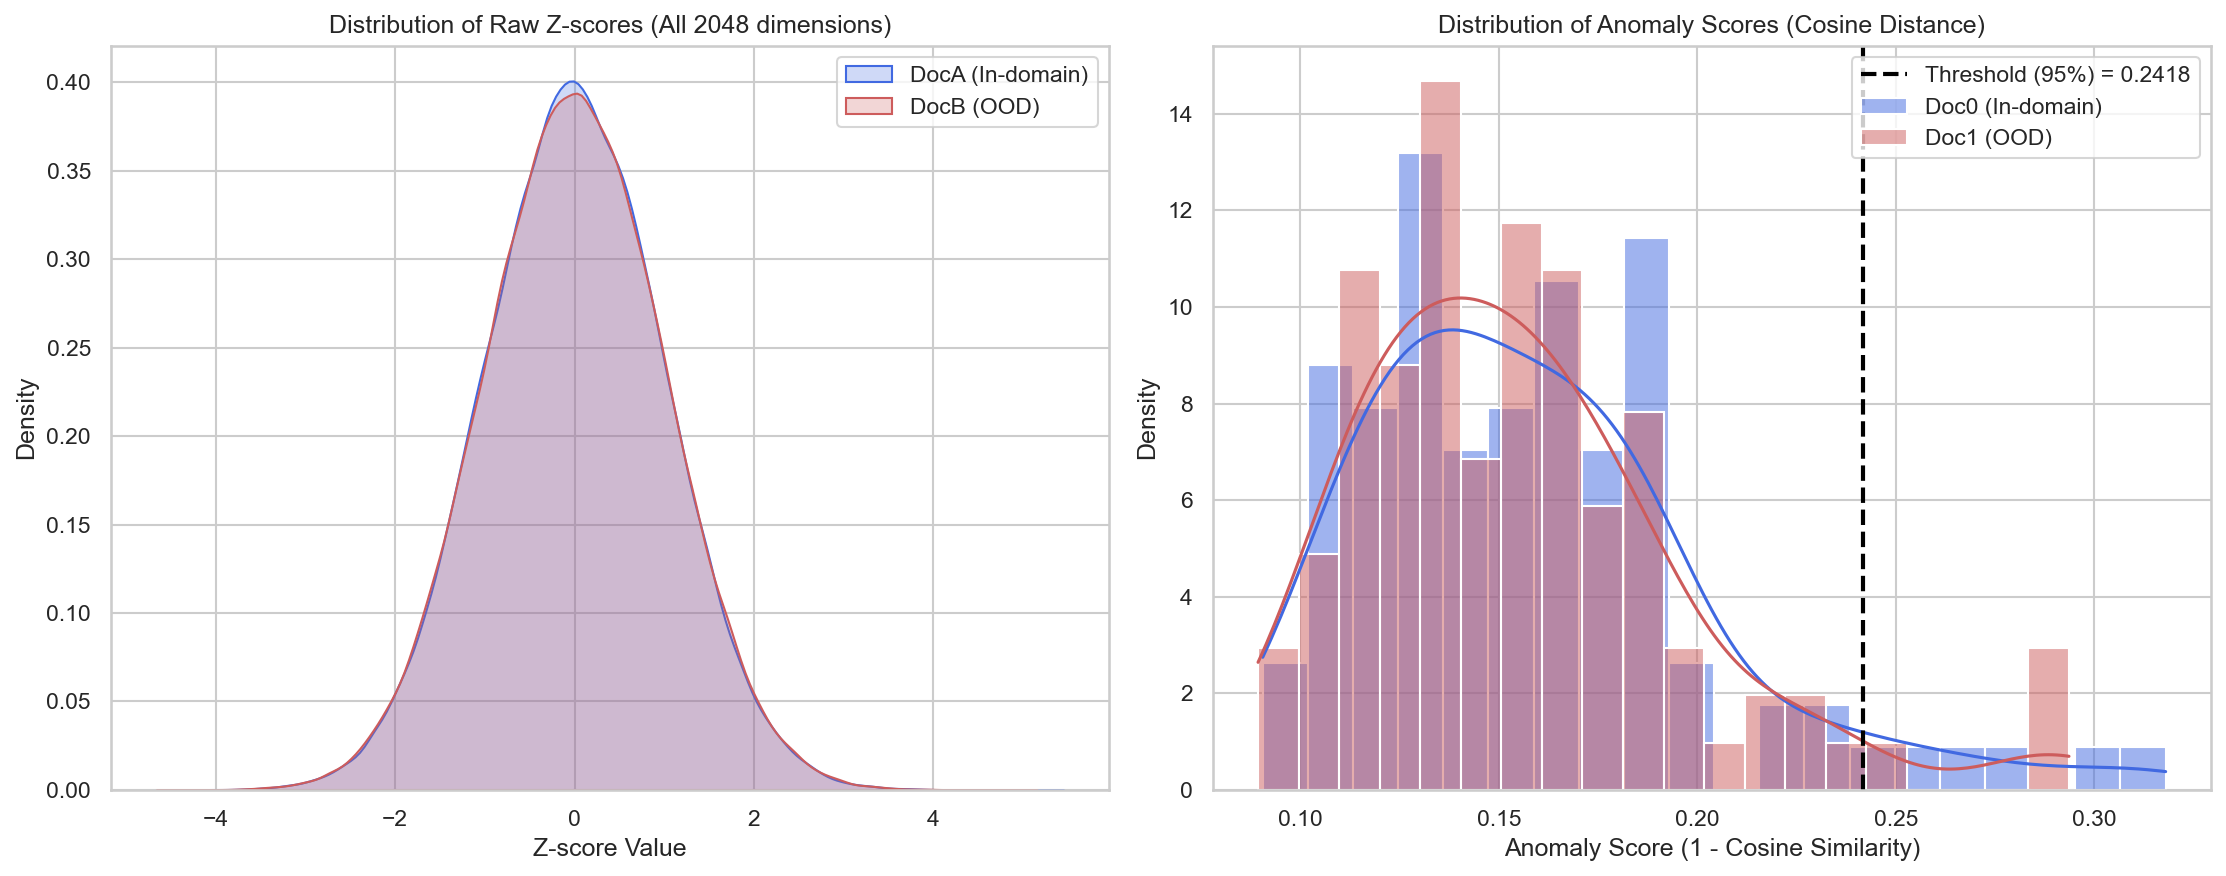

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics.pairwise import cosine_similarity

DATA_PATH = [
    "/Users/yoon/IRDMLab/PRAG/Q_noise_v2/output/pre/doc0_hidden_representation.json", 
    "/Users/yoon/IRDMLab/PRAG/Q_noise_v2/output/pre/doc1_hidden_representation.json"
]

doc0 = []
doc1 = []

for i, data in enumerate(DATA_PATH):
    with open(data, "r", encoding="utf-8") as f:
        doc_data = json.load(f)
    
    if i == 0:
        doc0.extend([item["hidden_representation"] for item in doc_data])
    else:
        doc1.extend([item["hidden_representation"] for item in doc_data])

data_matrix0 = np.array(doc0)
data_matrix1 = np.array(doc1)

print(data_matrix0.shape)
print(data_matrix1.shape)

# ==========================================
# 2. In-domain(doc0) 기준 프로필 및 Z-score 계산 (그래프 1 용도)
# ==========================================
mean0 = np.mean(data_matrix0, axis=0)
std0 = np.std(data_matrix0, axis=0) + 1e-8

z_scores_doc0 = (data_matrix0 - mean0) / std0
z_scores_doc1 = (data_matrix1 - mean0) / std0

# ==========================================
# 3. In-domain(doc0)의 중심(Centroid) 벡터 구하기
# ==========================================
# Doc0(정상) 문서들이 가리키는 평균적인 '방향'을 찾습니다.
centroid0 = np.mean(data_matrix0, axis=0).reshape(1, -1)

# ==========================================
# 4. Anomaly Score (Cosine Distance) 계산 (그래프 2 용도)
# ==========================================
# 각 문서의 벡터가 Doc0의 중심 방향과 얼마나 유사한지 각도(유사도)를 계산합니다.
sim_doc0 = cosine_similarity(data_matrix0, centroid0).flatten()
sim_doc1 = cosine_similarity(data_matrix1, centroid0).flatten()

# 유사도를 거리 개념(Anomaly Score)으로 뒤집기 위해 (1 - 유사도)를 사용합니다.
# 값이 클수록 In-domain 중심에서 각도가 많이 틀어진 이상(Anomaly) 데이터입니다.
anomaly_scores_doc0 = 1 - sim_doc0
anomaly_scores_doc1 = 1 - sim_doc1

# ==========================================
# 5. 시각화 (2개의 그래프를 나란히 비교)
# ==========================================
plt.rcParams['figure.dpi'] = 150
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- [그래프 1] 2048개 차원 전체의 Z-score 값 자체의 분포 ---
sns.kdeplot(z_scores_doc0.flatten(), fill=True, color="royalblue", label="DocA (In-domain)", ax=axes[0])
sns.kdeplot(z_scores_doc1.flatten(), fill=True, color="indianred", label="DocB (OOD)", ax=axes[0])

axes[0].set_title("Distribution of Raw Z-scores (All 2048 dimensions)")
axes[0].set_xlabel("Z-score Value")
axes[0].set_ylabel("Density")
axes[0].legend()

# --- [그래프 2] 최종 Anomaly Score (Cosine Distance) 분포 ---
sns.histplot(anomaly_scores_doc0, bins=20, color="royalblue", alpha=0.5, stat="density", kde=True, label="Doc0 (In-domain)", ax=axes[1])
sns.histplot(anomaly_scores_doc1, bins=20, color="indianred", alpha=0.5, stat="density", kde=True, label="Doc1 (OOD)", ax=axes[1])

# In-domain(doc0)의 상위 95% 지점에 Threshold 선 긋기
threshold_95 = np.percentile(anomaly_scores_doc0, 95)
axes[1].axvline(threshold_95, color='black', linestyle='--', linewidth=2, label=f'Threshold (95%) = {threshold_95:.4f}')

axes[1].set_title("Distribution of Anomaly Scores (Cosine Distance)")
axes[1].set_xlabel("Anomaly Score (1 - Cosine Similarity)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()